In [66]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import arff
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

# Data Loading

In [67]:
ROOT = Path.cwd()

if ROOT.name == 'notebooks':
    DATA_PATH = ROOT.parent / 'credit.arff'
else:
    DATA_PATH = 'credit.arff'
    
with open(DATA_PATH, 'r') as f:
    arff_data = arff.load(f)
    
data = arff_data['data']
column_names = [attr[0] for attr in arff_data['attributes']]
    
df = pd.DataFrame(data, columns=column_names)
df.head()

,Loan_ID,Loan_Amount_Requested,Length_Employed,Home_Owner,Annual_Income,Income_Verified,Purpose_Of_Loan,Debt_To_Income,Inquiries_Last_6Mo,Months_Since_Deliquency,Number_Open_Accounts,Total_Accounts,Gender,Interest_Rate
0,10139122,"35,000",3 years,NaN,160000.0,VERIFIED - income,credit_card,14.86,1,NaN,6,26,Male,None
1,10025461,"15,000",10+ years,Rent,41000.0,not verified,debt_consolidation,16.51,0,21.0,13,36,Female,None
2,10154747,"11,000",5 years,Mortgage,59000.0,not verified,debt_consolidation,21.75,0,NaN,11,20,Male,None
3,10032437,"12,000",NaN,Mortgage,72000.0,VERIFIED - income,debt_consolidation,15.73,1,NaN,7,20,Female,None
4,10060564,"20,000",< 1 year,Other,79404.0,VERIFIED - income,debt_consolidation,15.32,3,58.0,18,33,Female,None


# Mini EDA

In [68]:
df.info()
df.isna().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 32862 entries, 0 to 32861
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  32862 non-null  int64  
 1   Loan_Amount_Requested    32862 non-null  str    
 2   Length_Employed          31399 non-null  str    
 3   Home_Owner               27822 non-null  str    
 4   Annual_Income            27894 non-null  float64
 5   Income_Verified          32862 non-null  str    
 6   Purpose_Of_Loan          32862 non-null  str    
 7   Debt_To_Income           32862 non-null  float64
 8   Inquiries_Last_6Mo       32862 non-null  int64  
 9   Months_Since_Deliquency  15182 non-null  float64
 10  Number_Open_Accounts     32862 non-null  int64  
 11  Total_Accounts           32862 non-null  int64  
 12  Gender                   32862 non-null  str    
 13  Interest_Rate            0 non-null      object 
dtypes: float64(3), int64(4), object(1

Interest_Rate              32862
Months_Since_Deliquency    17680
Home_Owner                  5040
Annual_Income               4968
Length_Employed             1463
Loan_ID                        0
Loan_Amount_Requested          0
Income_Verified                0
Purpose_Of_Loan                0
Debt_To_Income                 0
Inquiries_Last_6Mo             0
Number_Open_Accounts           0
Total_Accounts                 0
Gender                         0
dtype: int64

In [69]:
df['Loan_Amount_Requested'].unique()

<ArrowStringArray>
['35,000', '15,000', '11,000', '12,000', '20,000', '19,850',  '7,000',
 '21,000', '18,000', '12,250',
 ...
 '23,100',  '4,225', '28,950', '22,925', '11,425', '32,250',  '2,825',
 '30,025', '25,550', '29,950']
Length: 1119, dtype: str

In [70]:
### Loan_Amount_Requested is str but could be changed to float, Length_Employed can be changed to 
df['Loan_Amount_Requested'] = df['Loan_Amount_Requested'].str.replace(',', '').astype(float)
df.dtypes

Loan_ID                      int64
Loan_Amount_Requested      float64
Length_Employed                str
Home_Owner                     str
Annual_Income              float64
Income_Verified                str
Purpose_Of_Loan                str
Debt_To_Income             float64
Inquiries_Last_6Mo           int64
Months_Since_Deliquency    float64
Number_Open_Accounts         int64
Total_Accounts               int64
Gender                         str
Interest_Rate               object
dtype: object

In [71]:
df.nunique()

Loan_ID                    32862
Loan_Amount_Requested       1119
Length_Employed               11
Home_Owner                     4
Annual_Income               3430
Income_Verified                3
Purpose_Of_Loan               14
Debt_To_Income              3638
Inquiries_Last_6Mo             8
Months_Since_Deliquency       98
Number_Open_Accounts          47
Total_Accounts                87
Gender                         2
Interest_Rate                  0
dtype: int64

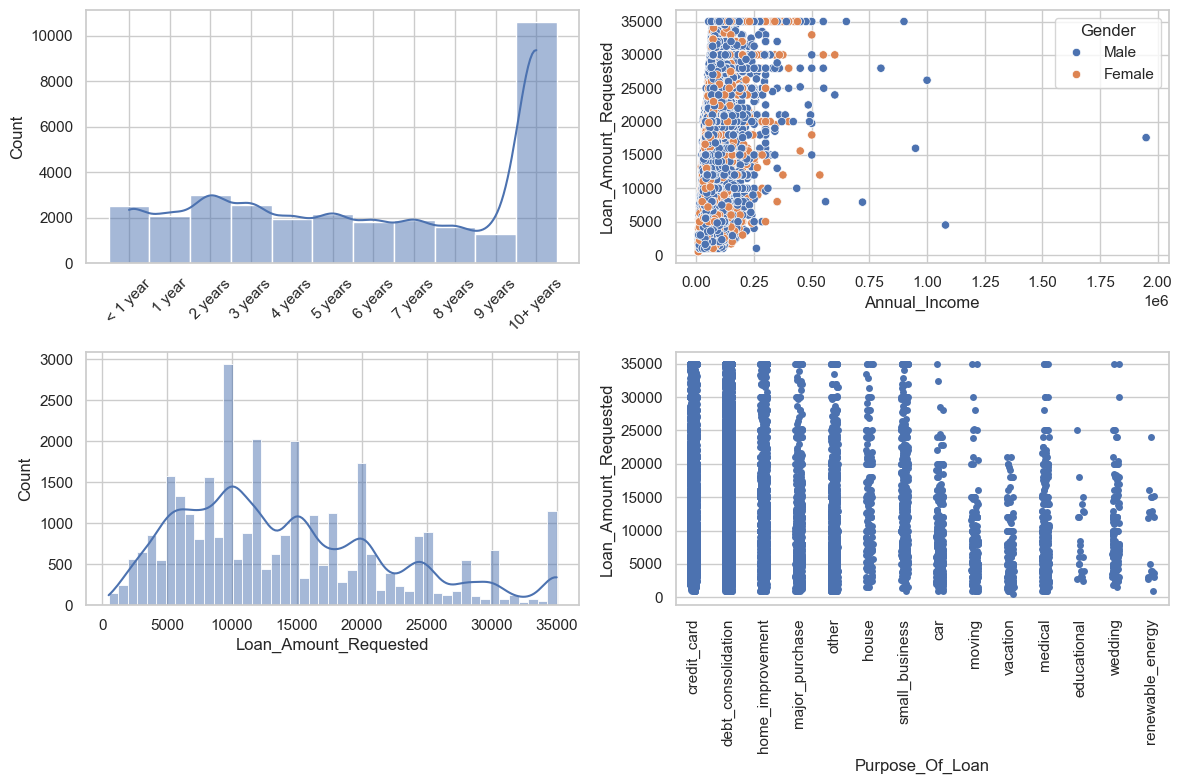

In [72]:
### the goal here is to see potential interesting patterns in data
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

order = ['< 1 year', '1 year', '2 years', '3 years', '4 years',
         '5 years', '6 years', '7 years', '8 years', '9 years', '10+ years']
col = pd.Series(pd.Categorical(df['Length_Employed'], categories=order, ordered=True))
sns.histplot(col.dropna(), kde=True, ax=ax[0][0])
ax[0][0].tick_params(axis='x', rotation=45)

sns.scatterplot(data=df, x='Annual_Income', y='Loan_Amount_Requested', hue='Gender', ax=ax[0][1])

col = pd.Series(df['Loan_Amount_Requested'])
sns.histplot(col.dropna(), kde=True, ax=ax[1][0])

sns.stripplot(data=df, x='Purpose_Of_Loan', y='Loan_Amount_Requested', ax=ax[1][1])
ax[1][1].tick_params(axis='x', rotation=90)

plt.tight_layout()

# Feature Preprocessing

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32862 entries, 0 to 32861
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  32862 non-null  int64  
 1   Loan_Amount_Requested    32862 non-null  float64
 2   Length_Employed          31399 non-null  str    
 3   Home_Owner               27822 non-null  str    
 4   Annual_Income            27894 non-null  float64
 5   Income_Verified          32862 non-null  str    
 6   Purpose_Of_Loan          32862 non-null  str    
 7   Debt_To_Income           32862 non-null  float64
 8   Inquiries_Last_6Mo       32862 non-null  int64  
 9   Months_Since_Deliquency  15182 non-null  float64
 10  Number_Open_Accounts     32862 non-null  int64  
 11  Total_Accounts           32862 non-null  int64  
 12  Gender                   32862 non-null  str    
 13  Interest_Rate            0 non-null      object 
dtypes: float64(4), int64(4), object(1

In [74]:
# not sure about using - Income_Verified, Inquiries_Last_6Mo, Months_Since_Deliquency, Total_Accounts
feature_columns = ['Loan_ID', 'Loan_Amount_Requested', 'Length_Employed', 'Annual_Income', 'Purpose_Of_Loan', 'Debt_To_Income',
                   'Number_Open_Accounts', 'Gender']
X = df[feature_columns].copy()

numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

# simple imputer chooses strategy for dealing with NaN values, standard scaler scales by removing the mean and scaling to unit variance
# one hot encoder encodes categorical features as a one-hot numeric array
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features),
])

X_prepared = preprocessor.fit_transform(X)
X_prepared.shape

(32862, 32)

# Clustering Analysis

- We will use KMeans clustering

Selected k=2 (highest Silhouette Score), cluster sizes:
cluster
0    12429
1    20433
dtype: int64


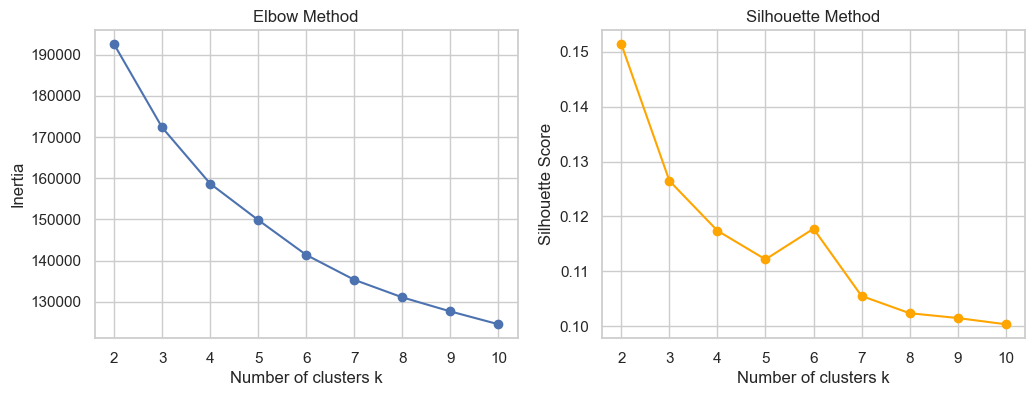

In [75]:
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    clusters = kmeans.fit_predict(X_prepared)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_prepared, labels=clusters))
    
k_final = k_range[np.argmax(silhouette_scores)]
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=20)
clusters = kmeans_final.fit_predict(X_prepared)

analysis_df = X.copy()
analysis_df['cluster'] = clusters
print(f"Selected k={k_final} (highest Silhouette Score), cluster sizes:")
print(analysis_df.groupby('cluster').size())
    
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
ax = axs[0]
ax.plot(k_range, inertias, marker='o')
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method')
ax.set_xticks(k_range)
ax.grid(True)

ax = axs[1]
ax.plot(k_range, silhouette_scores, marker='o', color='orange')
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Method')
ax.set_xticks(k_range)
ax.grid(True)

In [76]:
analysis_df.groupby('cluster')[numeric_features].mean()

,Loan_ID,Loan_Amount_Requested,Annual_Income,Debt_To_Income,Number_Open_Accounts
cluster,,,,,
0,1.008223e+07,21380.493201,98406.320582,19.631735,14.574785
1,1.008239e+07,9920.161014,56653.791142,15.753668,9.062840


# Data PCA

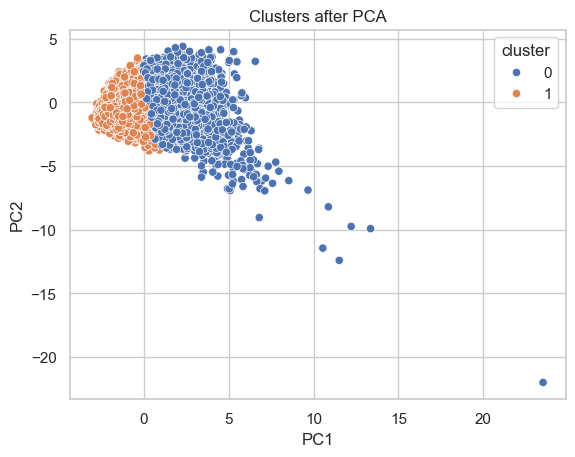

In [77]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_prepared)

plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'cluster': clusters.astype(str),
})

sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster")
plt.title("Clusters after PCA")
plt.show()